<a href="https://colab.research.google.com/github/draj05242-source/employee-attrition-prediction/blob/main/employee-attrition-prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Employee Attrition Prediction
### Predicting Employee Attrition Using Feature Engineering, Feature Selection and Classification Models

---
## Part 1: Data Understanding

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from xgboost import XGBClassifier

In [ ]:
# 1.1  Load the dataset
df = pd.read_csv('/content/Mentor 1 data set.csv')
print(f'Shape: {df.shape}')   # rows × columns

Shape: (1500, 19)


In [ ]:
# 1.2  Rows and columns
print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')

Rows   : 1500
Columns: 19


In [ ]:
#1.3  Identify categorical and numerical variables
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

print('Categorical columns:', cat_cols)
print('\nNumerical columns  :', num_cols)

Categorical columns: ['Employee_ID', 'Gender', 'Education_Level', 'Overtime', 'Department', 'Marital_Status', 'Business_Travel', 'Remote_Work']

Numerical columns  : ['Age', 'Years_At_Company', 'Job_Level', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Performance_Rating', 'Promotion_Last_3Yrs', 'Distance_From_Home_KM', 'Job_Satisfaction', 'Training_Hours', 'Attrition']


In [ ]:
df.head()

,Employee_ID,Age,Gender,Education_Level,Years_At_Company,Job_Level,Monthly_Salary,Overtime,Work_Hours_Per_Week,Performance_Rating,Promotion_Last_3Yrs,Distance_From_Home_KM,Job_Satisfaction,Training_Hours,Department,Marital_Status,Business_Travel,Remote_Work,Attrition
0,E100000,37,Male,Bachelor,8,2,14231,Yes,51,2,0,2.5,6.4,22.0,Sales,Married,Rarely,No,0
1,E100001,33,Female,Master,7,2,17091,Yes,54,3,0,23.3,6.6,45.0,Technology,Single,Rarely,Hybrid,1
2,E100002,39,Male,MBA,10,3,17535,No,42,4,0,8.8,6.7,41.0,Finance,Married,Rarely,Hybrid,0
3,E100003,45,Male,MBA,13,5,22005,No,43,3,0,4.8,8.9,26.0,Finance,Single,Frequently,Hybrid,0
4,E100004,32,Male,Bachelor,4,3,17139,Yes,59,2,0,43.0,5.8,41.0,Technology,Single,Rarely,No,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Employee_ID            1500 non-null   object 
 1   Age                    1500 non-null   int64  
 2   Gender                 1500 non-null   object 
 3   Education_Level        1478 non-null   object 
 4   Years_At_Company       1500 non-null   int64  
 5   Job_Level              1500 non-null   int64  
 6   Monthly_Salary         1500 non-null   int64  
 7   Overtime               1500 non-null   object 
 8   Work_Hours_Per_Week    1500 non-null   int64  
 9   Performance_Rating     1500 non-null   int64  
 10  Promotion_Last_3Yrs    1500 non-null   int64  
 11  Distance_From_Home_KM  1470 non-null   float64
 12  Job_Satisfaction       1455 non-null   float64
 13  Training_Hours         1463 non-null   float64
 14  Department             1500 non-null   object 
 15  Mari

In [ ]:
df.describe()

,Age,Years_At_Company,Job_Level,Monthly_Salary,Work_Hours_Per_Week,Performance_Rating,Promotion_Last_3Yrs,Distance_From_Home_KM,Job_Satisfaction,Training_Hours,Attrition
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1470.000000,1455.000000,1463.000000,1500.000000
mean,34.394667,6.464667,3.052667,15899.858000,47.740667,3.228000,0.114000,14.233265,6.199931,32.565960,0.105333
std,6.786084,3.759899,1.202854,3110.333245,6.714522,0.834554,0.317917,9.684865,1.845577,10.713831,0.307085
min,21.000000,0.000000,1.000000,6722.000000,32.000000,1.000000,0.000000,1.000000,1.000000,4.000000,0.000000
25%,30.000000,4.000000,2.000000,13615.500000,43.000000,3.000000,0.000000,6.700000,5.000000,25.000000,0.000000
50%,34.000000,6.000000,3.000000,15920.500000,47.500000,3.000000,0.000000,11.850000,6.300000,33.000000,0.000000
75%,39.000000,9.000000,4.000000,18104.500000,53.000000,4.000000,0.000000,19.500000,7.500000,40.000000,0.000000
max,58.000000,19.000000,5.000000,24612.000000,66.000000,5.000000,1.000000,45.000000,10.000000,67.000000,1.000000


Attrition distribution:
           Count  Percentage
Attrition                   
0           1342       89.47
1            158       10.53


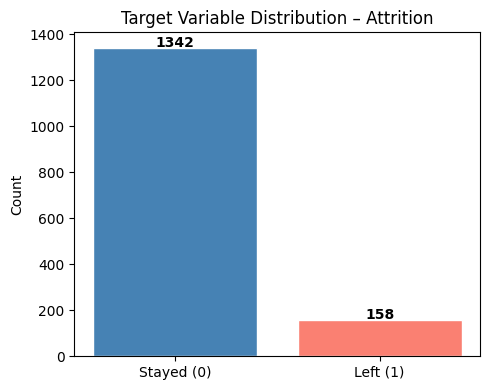


Class imbalance ratio  →  Stayed : Left = 1342:158


In [ ]:
#1.4  Target variable distribution
attrition_counts = df['Attrition'].value_counts()
attrition_pct    = df['Attrition'].value_counts(normalize=True) * 100

print('Attrition distribution:')
print(pd.DataFrame({'Count': attrition_counts, 'Percentage': attrition_pct.round(2)}))

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Stayed (0)', 'Left (1)'], attrition_counts.values,
       color=['steelblue', 'salmon'], edgecolor='white')
for i, v in enumerate(attrition_counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
ax.set_title('Target Variable Distribution – Attrition')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

print(f'\nClass imbalance ratio  →  Stayed : Left = {attrition_counts[0]}:{attrition_counts[1]}')

---
## Part 2: Data Cleaning

Columns with missing values:
Job_Satisfaction         45
Training_Hours           37
Distance_From_Home_KM    30
Education_Level          22
dtype: int64


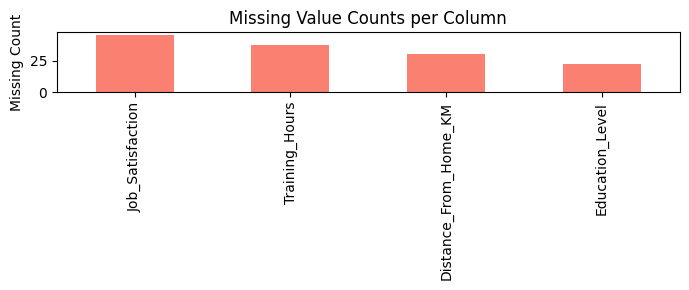

In [ ]:
#2.1  Check for missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print('Columns with missing values:')
print(missing)

fig, ax = plt.subplots(figsize=(7, 3))
missing.plot(kind='bar', color='salmon', ax=ax)
ax.set_title('Missing Value Counts per Column')
ax.set_ylabel('Missing Count')
plt.tight_layout()
plt.show()

In [ ]:
#2.2  Handle missing values
# Numerical - median imputation (robust to skew)
for col in ['Distance_From_Home_KM', 'Job_Satisfaction', 'Training_Hours']:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)
    print(f'  {col}: filled {missing.get(col, 0)} nulls with median = {median_val:.2f}')

# Categorical → mode imputation
for col in ['Education_Level']:
    mode_val = df[col].mode()[0]
    df[col].fillna(mode_val, inplace=True)
    print(f'  {col}: filled {missing.get(col, 0)} nulls with mode = "{mode_val}"')

print(f'\nRemaining missing values: {df.isnull().sum().sum()}')

  Distance_From_Home_KM: filled 30 nulls with median = 11.85
  Job_Satisfaction: filled 45 nulls with median = 6.30
  Training_Hours: filled 37 nulls with median = 33.00
  Education_Level: filled 22 nulls with mode = "Bachelor"

Remaining missing values: 0


In [ ]:
# 2.3  Remove duplicates
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
if dupes > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates removed.')

Duplicate rows: 0


In [ ]:
# 2.4  Verify data types
print(df.dtypes)
print(f'\nDataset shape after cleaning: {df.shape}')

Employee_ID               object
Age                        int64
Gender                    object
Education_Level           object
Years_At_Company           int64
Job_Level                  int64
Monthly_Salary             int64
Overtime                  object
Work_Hours_Per_Week        int64
Performance_Rating         int64
Promotion_Last_3Yrs        int64
Distance_From_Home_KM    float64
Job_Satisfaction         float64
Training_Hours           float64
Department                object
Marital_Status            object
Business_Travel           object
Remote_Work               object
Attrition                  int64
dtype: object

Dataset shape after cleaning: (1500, 19)


---
## Part 3: Feature Engineering

In [ ]:
#  3.1  Work Pressure Index
# Higher ratio → more hours per unit of satisfaction → more pressure
df['Work_Pressure_Index'] = df['Work_Hours_Per_Week'] / (df['Job_Satisfaction'] + 1e-6)

#  3.2  Salary Per Level
# Compensation fairness relative to seniority level
df['Salary_Per_Level'] = df['Monthly_Salary'] / df['Job_Level']

# 3.3  Commute Stress
# Long commute combined with long hours amplifies burnout risk
df['Commute_Stress'] = df['Distance_From_Home_KM'] * df['Work_Hours_Per_Week']

# 3.4  Experience Category
# Tenure-based segmentation
def experience_category(years):
    if years <= 2:   return 'New'
    elif years <= 5: return 'Junior'
    elif years <= 10: return 'Mid'
    else:            return 'Senior'

df['Experience_Category'] = df['Years_At_Company'].apply(experience_category)

# 3.5  Performance-Satisfaction Gap
# High performers with low satisfaction - flight risk
df['Perf_Sat_Gap'] = df['Performance_Rating'] - df['Job_Satisfaction']

#  3.6  Low_Pay_High_Hours flag
salary_q25 = df['Monthly_Salary'].quantile(0.25)
hours_q75  = df['Work_Hours_Per_Week'].quantile(0.75)
df['Low_Pay_High_Hours'] = ((df['Monthly_Salary'] <= salary_q25) &
                             (df['Work_Hours_Per_Week'] >= hours_q75)).astype(int)

engineered_features = ['Work_Pressure_Index', 'Salary_Per_Level', 'Commute_Stress',
                        'Experience_Category', 'Perf_Sat_Gap', 'Low_Pay_High_Hours']

print('Engineered features created:')
print(df[engineered_features].head(10))

Engineered features created:
   Work_Pressure_Index  Salary_Per_Level  Commute_Stress Experience_Category  \
0             7.968749       7115.500000           127.5                 Mid   
1             8.181817       8545.500000          1258.2                 Mid   
2             6.268656       5845.000000           369.6                 Mid   
3             4.831460       4401.000000           206.4              Senior   
4            10.172412       5713.000000          2537.0              Junior   
5             7.187499       7809.000000           317.4                 New   
6             4.000000       6009.333333          1204.0              Senior   
7             8.115941       4472.400000           851.2              Senior   
8             5.749999       4860.000000           809.6                 Mid   
9             8.604649       3907.400000           444.0                 Mid   

   Perf_Sat_Gap  Low_Pay_High_Hours  
0          -4.4                   0  
1          -3.

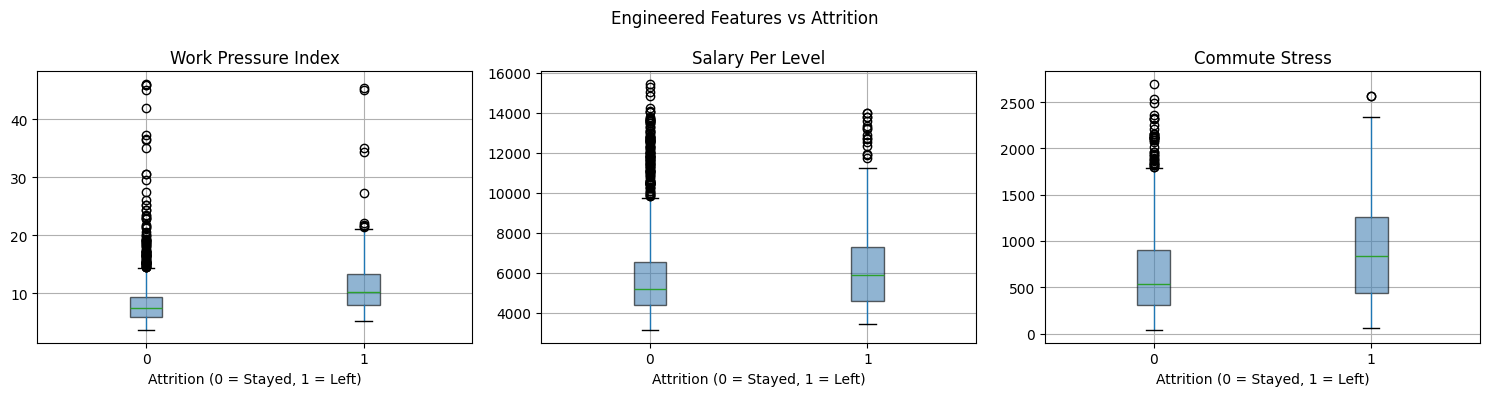

In [ ]:
#  Visualise engineered features vs Attrition
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feat, title in zip(
    axes,
    ['Work_Pressure_Index', 'Salary_Per_Level', 'Commute_Stress'],
    ['Work Pressure Index', 'Salary Per Level', 'Commute Stress']):

    df.boxplot(column=feat, by='Attrition', ax=ax,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(title)
    ax.set_xlabel('Attrition (0 = Stayed, 1 = Left)')

plt.suptitle('Engineered Features vs Attrition')
plt.tight_layout()
plt.show()

---
## Part 4: Feature Selection

In [ ]:
#  Encode categorical columns
df_model = df.drop(columns=['Employee_ID'])  # drop ID – no predictive value

le = LabelEncoder()
cat_encode_cols = df_model.select_dtypes(include='object').columns.tolist()
for col in cat_encode_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (1500, 23)


Correlation with Attrition (top 10):
Work_Pressure_Index      0.214223
Job_Satisfaction         0.205395
Overtime                 0.202954
Work_Hours_Per_Week      0.186350
Perf_Sat_Gap             0.181937
Low_Pay_High_Hours       0.165712
Commute_Stress           0.160256
Distance_From_Home_KM    0.123591
Job_Level                0.099912
Salary_Per_Level         0.095608
dtype: float64


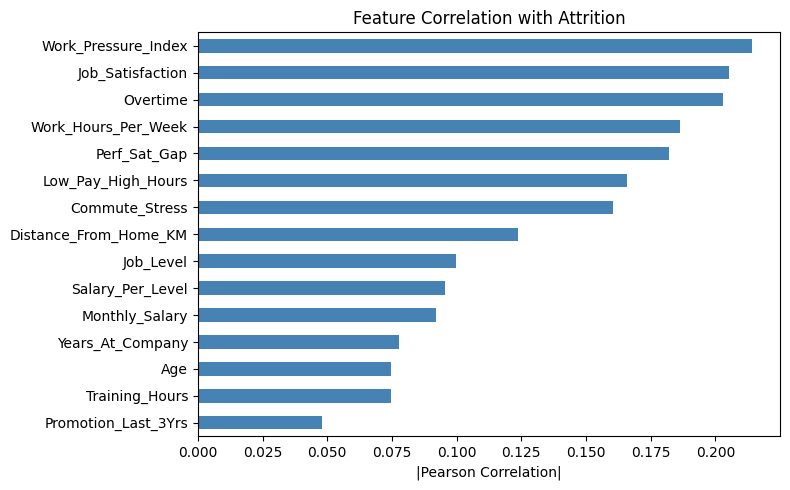

In [ ]:
#  4.1  Correlation matrix (numerical features)
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print('Correlation with Attrition (top 10):')
print(corr_with_target.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
corr_with_target.head(15).plot(kind='barh', color='steelblue', ax=ax)
ax.invert_yaxis()
ax.set_title('Feature Correlation with Attrition')
ax.set_xlabel('|Pearson Correlation|')
plt.tight_layout()
plt.show()

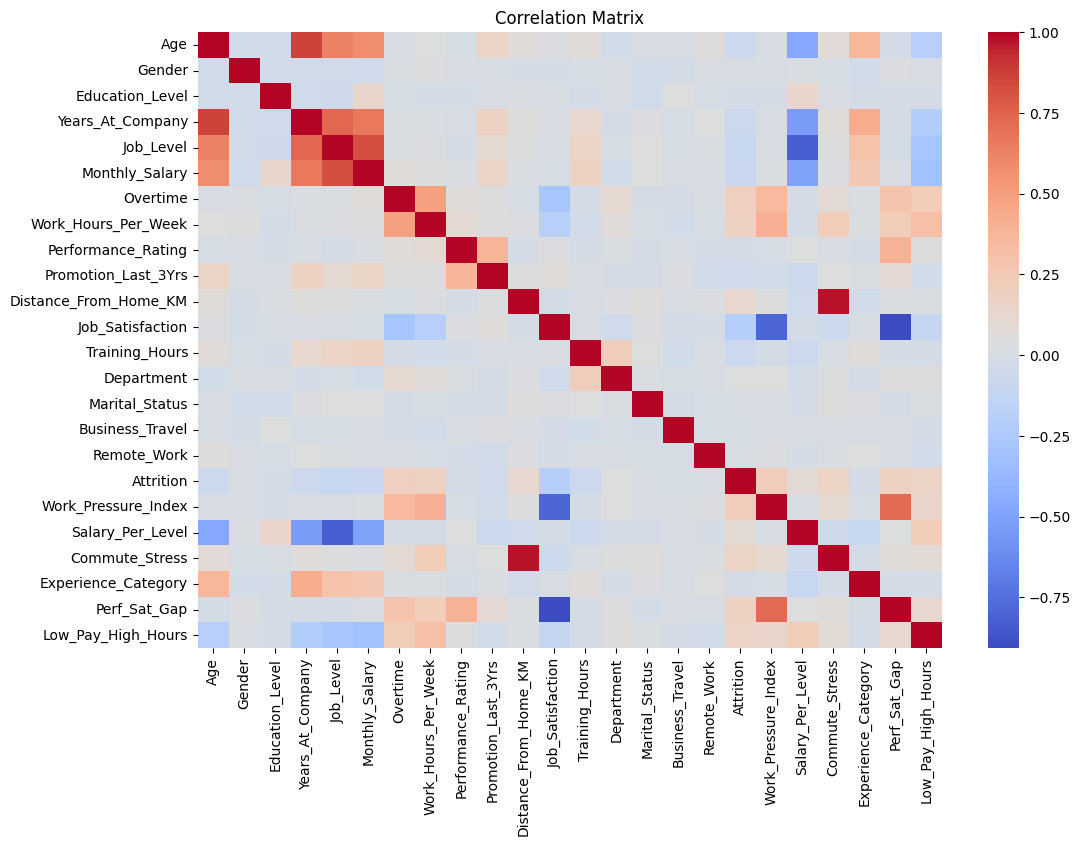

Top 10 Features Based on Correlation:
Work_Pressure_Index      0.214223
Job_Satisfaction         0.205395
Overtime                 0.202954
Work_Hours_Per_Week      0.186350
Perf_Sat_Gap             0.181937
Low_Pay_High_Hours       0.165712
Commute_Stress           0.160256
Distance_From_Home_KM    0.123591
Job_Level                0.099912
Salary_Per_Level         0.095608
Name: Attrition, dtype: float64


In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(df_model.corr(), cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()
corr_matrix = df_model.corr()

# Step 2: get correlation with target variable
target_corr = corr_matrix['Attrition']

# Step 3: remove target itself
target_corr = target_corr.drop('Attrition')

# Step 4: sort by absolute correlation
top_features = target_corr.abs().sort_values(ascending=False)

# Step 5: extract top 10 features
top_10_features = top_features.head(10)

print("Top 10 Features Based on Correlation:")
print(top_10_features)

RF Feature Importance (top 10):
Work_Pressure_Index      0.090173
Commute_Stress           0.084010
Distance_From_Home_KM    0.078774
Salary_Per_Level         0.075526
Monthly_Salary           0.072738
Job_Satisfaction         0.071798
Perf_Sat_Gap             0.069619
Training_Hours           0.063584
Work_Hours_Per_Week      0.060021
Age                      0.059073
dtype: float64


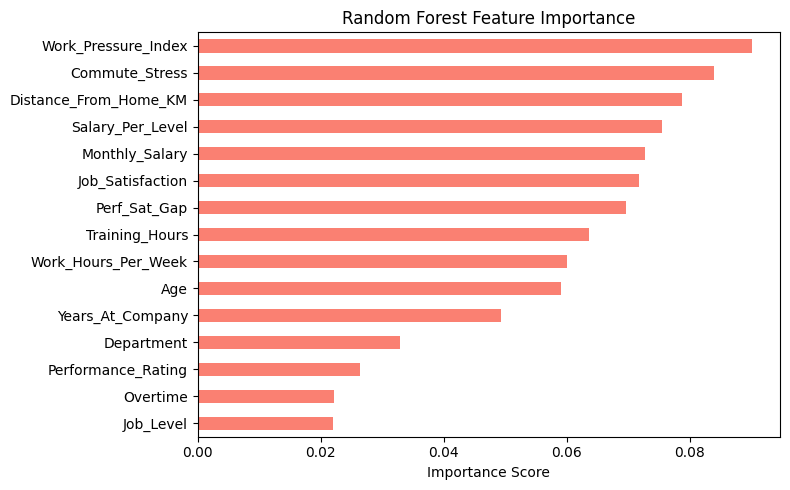

In [ ]:
# 4.2  Random Forest Feature Importance
rf_fs = RandomForestClassifier(n_estimators=200, random_state=42)
rf_fs.fit(X, y)

rf_importance = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)
print('RF Feature Importance (top 10):')
print(rf_importance.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
rf_importance.head(15).plot(kind='barh', color='salmon', ax=ax)
ax.invert_yaxis()
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

Mutual Information (top 10):
Work_Pressure_Index    0.026749
Perf_Sat_Gap           0.021202
Job_Satisfaction       0.018117
Overtime               0.016331
Low_Pay_High_Hours     0.013519
Work_Hours_Per_Week    0.009926
Age                    0.009024
Years_At_Company       0.005377
Commute_Stress         0.003122
Remote_Work            0.003039
dtype: float64


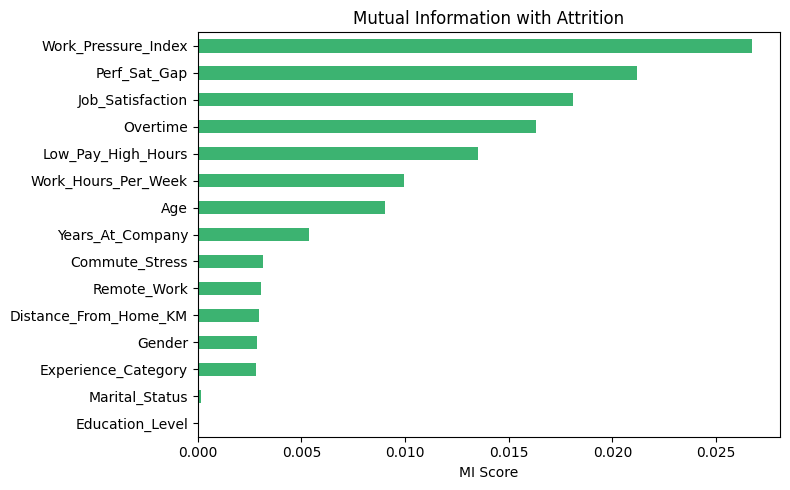

In [ ]:
# 4.3  Mutual Information
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print('Mutual Information (top 10):')
print(mi_series.head(10))

fig, ax = plt.subplots(figsize=(8, 5))
mi_series.head(15).plot(kind='barh', color='mediumseagreen', ax=ax)
ax.invert_yaxis()
ax.set_title('Mutual Information with Attrition')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.show()

In [ ]:
# 4.4  Recursive Feature Elimination (RFE)
rfe_estimator = RandomForestClassifier(n_estimators=50, random_state=42)
rfe = RFE(estimator=rfe_estimator, n_features_to_select=10, step=1)
rfe.fit(X, y)

rfe_selected = X.columns[rfe.support_].tolist()
print('Features selected by RFE:', rfe_selected)

Features selected by RFE: ['Age', 'Monthly_Salary', 'Work_Hours_Per_Week', 'Distance_From_Home_KM', 'Job_Satisfaction', 'Training_Hours', 'Work_Pressure_Index', 'Salary_Per_Level', 'Commute_Stress', 'Perf_Sat_Gap']


In [ ]:
# 4.5  Aggregate rankings → Top 5 Most Important Features
# Rank each method (lower rank = more important)
corr_rank = corr_with_target.rank(ascending=False)
rf_rank   = rf_importance.rank(ascending=False)
mi_rank   = mi_series.rank(ascending=False)

rank_df = pd.DataFrame({'Correlation_Rank': corr_rank,
                         'RF_Rank':          rf_rank,
                         'MI_Rank':           mi_rank})
rank_df['Average_Rank'] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values('Average_Rank')

top5 = rank_df.head(5).index.tolist()
print('\n🏆 TOP 5 MOST IMPORTANT FEATURES (consensus ranking):')
for i, feat in enumerate(top5, 1):
    print(f'  {i}. {feat}')

print('\nFull ranking table:')
print(rank_df.head(10).round(2))


🏆 TOP 5 MOST IMPORTANT FEATURES (consensus ranking):
  1. Work_Pressure_Index
  2. Job_Satisfaction
  3. Perf_Sat_Gap
  4. Commute_Stress
  5. Work_Hours_Per_Week

Full ranking table:
                       Correlation_Rank  RF_Rank  MI_Rank  Average_Rank
Work_Pressure_Index                 1.0      1.0      1.0          1.00
Job_Satisfaction                    2.0      6.0      3.0          3.67
Perf_Sat_Gap                        5.0      7.0      2.0          4.67
Commute_Stress                      7.0      2.0      9.0          6.00
Work_Hours_Per_Week                 4.0      9.0      6.0          6.33
Overtime                            3.0     14.0      4.0          7.00
Distance_From_Home_KM               8.0      3.0     11.0          7.33
Age                                13.0     10.0      7.0         10.00
Years_At_Company                   12.0     11.0      8.0         10.33
Salary_Per_Level                   10.0      4.0     19.0         11.00


---
## Part 5: Model Building

In [ ]:
# Train / Test split
# Use the RFE-selected features (10 features) for model training
X_selected = X[rfe_selected]

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set : {X_train.shape[0]} samples')
print(f'Test set     : {X_test.shape[0]} samples')
print(f'Attrition in test set: {y_test.value_counts().to_dict()}')

Training set : 1200 samples
Test set     : 300 samples
Attrition in test set: {0: 268, 1: 32}


In [ ]:
#  Scale features
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [ ]:
# Model 1: Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    class_weight='balanced',   # handles class imbalance
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)
print('Random Forest trained.')

Random Forest trained.


In [ ]:
# Model 2: XGBoost
# scale_pos_weight handles class imbalance for XGBoost
neg, pos = np.bincount(y_train)
scale_pos = neg / pos

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_scaled, y_train)
print('XGBoost trained.')

XGBoost trained.


In [ ]:
# Model 3: Gradient Boosting
# Builds trees sequentially like XGBoost but uses sklearn's native implementation.
# Uses class_weight via sample_weight workaround — we pass sample weights manually.

from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    min_samples_leaf=5,
    random_state=42
)
gb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print("Gradient Boosting trained.")

Gradient Boosting trained.


---
## Part 6: Model Evaluation

In [ ]:
#  Helper: compute all metrics
def evaluate_model(model, X_test, y_test, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred),  4),
        'Precision': round(precision_score(y_test, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred),    4),
        'F1 Score' : round(f1_score(y_test, y_pred),        4),
        'ROC AUC'  : round(roc_auc_score(y_test, y_proba),  4),
    }, model.predict(X_test), model.predict_proba(X_test)[:, 1]

# Evaluate all 3 models
rf_metrics,  rf_pred,  rf_proba  = evaluate_model(rf_model,  X_test_scaled, y_test, 'Random Forest')
xgb_metrics, xgb_pred, xgb_proba = evaluate_model(xgb_model, X_test_scaled, y_test, 'XGBoost')
gb_metrics,  gb_pred,  gb_proba  = evaluate_model(gb_model,  X_test_scaled, y_test, 'Gradient Boosting')

results_df = pd.DataFrame([rf_metrics, xgb_metrics, gb_metrics]).set_index('Model')

print("\n" + "="*65)
print("          3-MODEL COMPARISON TABLE")
print("="*65)
print(results_df.to_string())
print("="*65)
print(f"\nBest Recall  : {results_df['Recall'].idxmax()}  ({results_df['Recall'].max():.4f})")
print(f"Best ROC AUC : {results_df['ROC AUC'].idxmax()}  ({results_df['ROC AUC'].max():.4f})")
print(f"Best F1 Score: {results_df['F1 Score'].idxmax()}  ({results_df['F1 Score'].max():.4f})")



          3-MODEL COMPARISON TABLE
                   Accuracy  Precision  Recall  F1 Score  ROC AUC
Model                                                            
Random Forest        0.8600     0.2917  0.2188    0.2500   0.6544
XGBoost              0.8600     0.2222  0.1250    0.1600   0.5982
Gradient Boosting    0.8333     0.1538  0.1250    0.1379   0.6114

Best Recall  : Random Forest  (0.2188)
Best ROC AUC : Random Forest  (0.6544)
Best F1 Score: Random Forest  (0.2500)


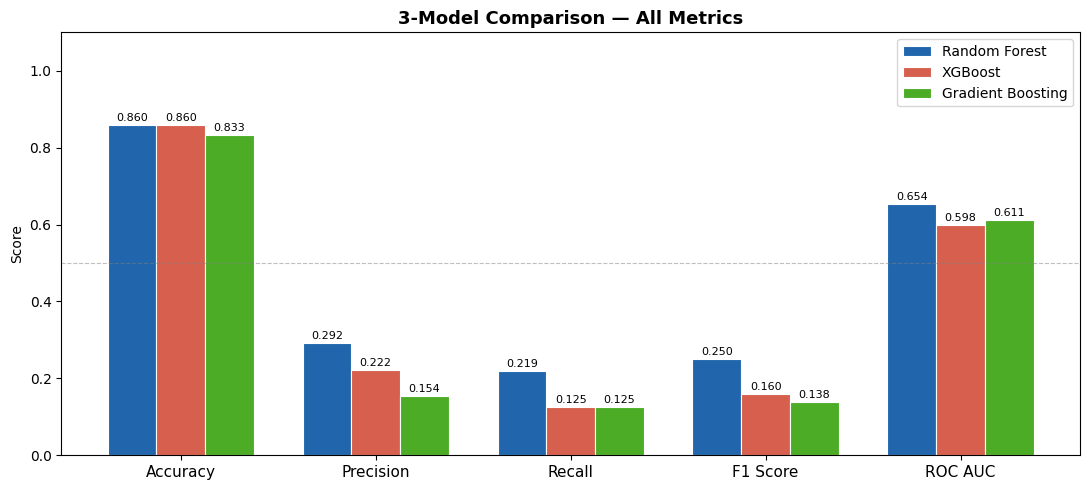

In [ ]:
#  Plot 1: Metrics Bar Chart
fig, ax = plt.subplots(figsize=(11, 5))

x      = np.arange(len(results_df.columns))
width  = 0.25
colors = ['#2166ac', '#d6604d', '#4dac26']

for i, (model_name, row) in enumerate(results_df.iterrows()):
    bars = ax.bar(x + i * width, row.values, width,
                  label=model_name, color=colors[i],
                  edgecolor='white', linewidth=0.8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(results_df.columns, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('3-Model Comparison — All Metrics', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, label='Baseline (0.5)')
plt.tight_layout()
plt.show()

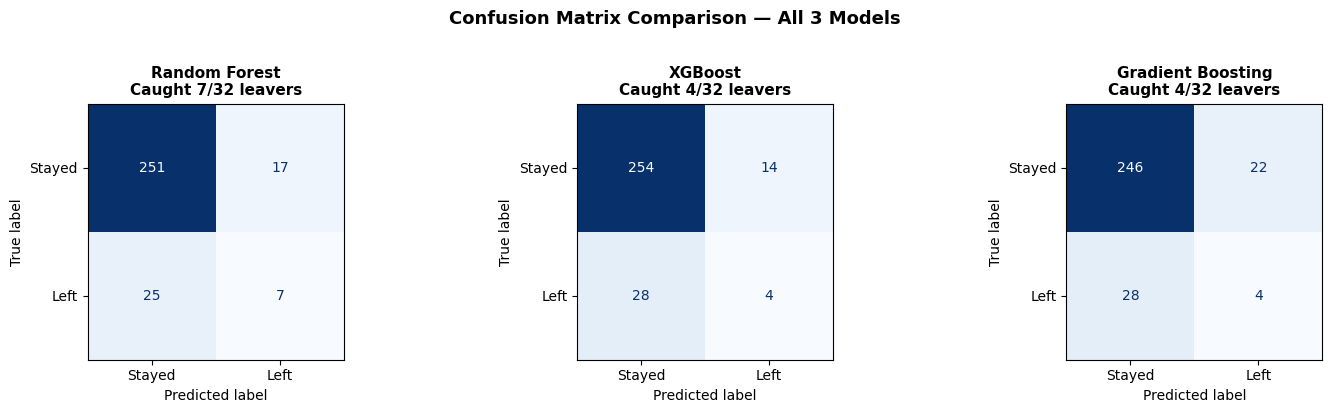

In [ ]:
#  Plot 2: Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

model_info = [
    (rf_model,  rf_pred,  'Random Forest',      '#2166ac'),
    (xgb_model, xgb_pred, 'XGBoost',            '#d6604d'),
    (gb_model,  gb_pred,  'Gradient Boosting',  '#4dac26'),
]

for ax, (model, pred, title, color) in zip(axes, model_info):
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred,
        display_labels=['Stayed', 'Left'],
        colorbar=False, ax=ax,
        cmap='Blues'
    )
    tp = ((pred == 1) & (y_test == 1)).sum()
    fn = ((pred == 0) & (y_test == 1)).sum()
    ax.set_title(f'{title}\nCaught {tp}/{tp+fn} leavers',
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix Comparison — All 3 Models', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

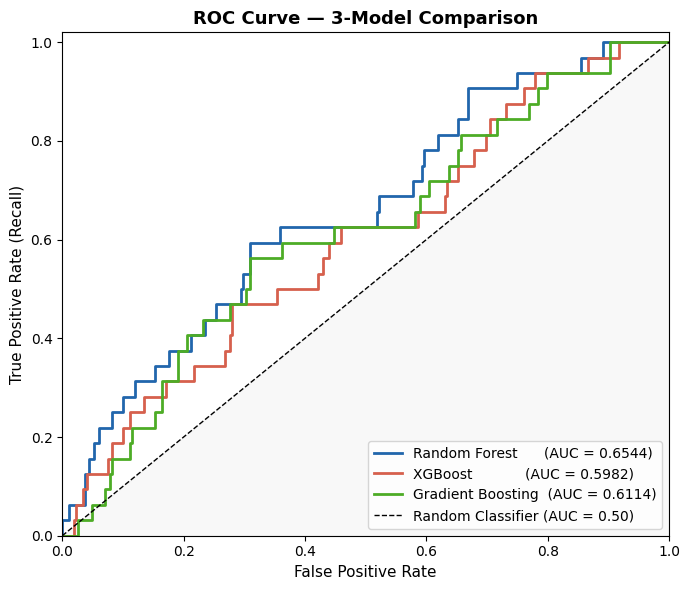

In [ ]:
#  Plot 3: ROC Curves
fig, ax = plt.subplots(figsize=(7, 6))

roc_data = [
    (rf_proba,  f"Random Forest      (AUC = {rf_metrics['ROC AUC']:.4f})",  '#2166ac'),
    (xgb_proba, f"XGBoost            (AUC = {xgb_metrics['ROC AUC']:.4f})", '#d6604d'),
    (gb_proba,  f"Gradient Boosting  (AUC = {gb_metrics['ROC AUC']:.4f})",  '#4dac26'),
]

for proba, label, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax.plot(fpr, tpr, label=label, color=color, lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC = 0.50)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=11)
ax.set_title('ROC Curve — 3-Model Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

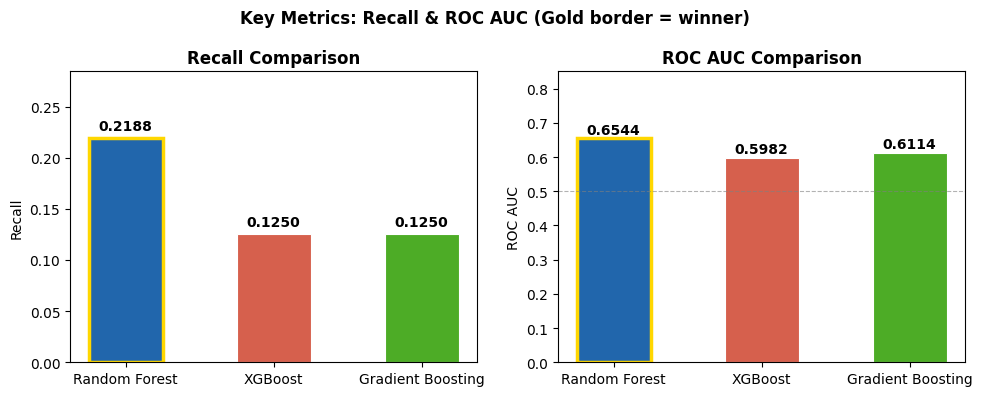

In [ ]:
#  Plot 4: Recall & ROC AUC focused comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

key_metrics = ['Recall', 'ROC AUC']
bar_colors  = ['#2166ac', '#d6604d', '#4dac26']

for ax, metric in zip(axes, key_metrics):
    vals   = results_df[metric].values
    models = results_df.index.tolist()
    bars   = ax.bar(models, vals, color=bar_colors, edgecolor='white', linewidth=0.8, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.005,
                f'{v:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, max(vals) * 1.3)
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    # Highlight the winner
    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(2.5)

plt.suptitle('Key Metrics: Recall & ROC AUC (Gold border = winner)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
#  Classification reports for all 3
for name, pred in [('Random Forest', rf_pred),
                   ('XGBoost', xgb_pred),
                   ('Gradient Boosting', gb_pred)]:
    print(f"\n── {name} ──")
    print(classification_report(y_test, pred, target_names=['Stayed', 'Left']))


── Random Forest ──
              precision    recall  f1-score   support

      Stayed       0.91      0.94      0.92       268
        Left       0.29      0.22      0.25        32

    accuracy                           0.86       300
   macro avg       0.60      0.58      0.59       300
weighted avg       0.84      0.86      0.85       300


── XGBoost ──
              precision    recall  f1-score   support

      Stayed       0.90      0.95      0.92       268
        Left       0.22      0.12      0.16        32

    accuracy                           0.86       300
   macro avg       0.56      0.54      0.54       300
weighted avg       0.83      0.86      0.84       300


── Gradient Boosting ──
              precision    recall  f1-score   support

      Stayed       0.90      0.92      0.91       268
        Left       0.15      0.12      0.14        32

    accuracy                           0.83       300
   macro avg       0.53      0.52      0.52       300
weighted avg 

In [ ]:
#  Final verdict
print("\n" + "="*65)
print("  FINAL MODEL SELECTION VERDICT")
print("="*65)
best_recall  = results_df['Recall'].idxmax()
best_auc     = results_df['ROC AUC'].idxmax()
best_f1      = results_df['F1 Score'].idxmax()
print(f"  Best Recall   → {best_recall}")
print(f"  Best ROC AUC  → {best_auc}")
print(f"  Best F1 Score → {best_f1}")
print(f"\n   SELECTED: {best_recall}")
print("  Rationale: In HR attrition prediction, Recall is the")
print("  most critical metric — missing a leaver costs the business")
print("  more than a false alarm. The model with the highest Recall")
print("  catches the most at-risk employees for HR intervention.")
print("="*65)


  FINAL MODEL SELECTION VERDICT
  Best Recall   → Random Forest
  Best ROC AUC  → Random Forest
  Best F1 Score → Random Forest

   SELECTED: Random Forest
  Rationale: In HR attrition prediction, Recall is the
  most critical metric — missing a leaver costs the business
  more than a false alarm. The model with the highest Recall
  catches the most at-risk employees for HR intervention.


---
## Part 7: Business Interpretation

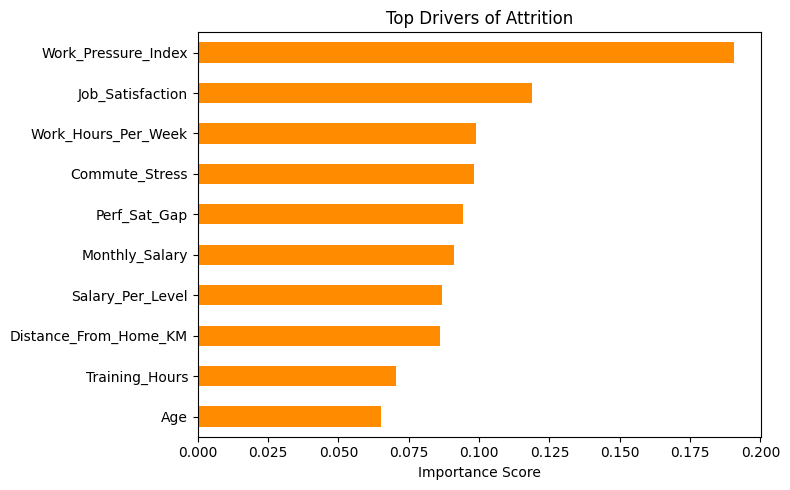

Top drivers:
  1. Work_Pressure_Index: 0.1907
  2. Job_Satisfaction: 0.1189
  3. Work_Hours_Per_Week: 0.0988
  4. Commute_Stress: 0.0982
  5. Perf_Sat_Gap: 0.0943
  6. Monthly_Salary: 0.0909
  7. Salary_Per_Level: 0.0866
  8. Distance_From_Home_KM: 0.0862
  9. Training_Hours: 0.0703
  10. Age: 0.0651


In [ ]:
# 7.1  Top Drivers of Employee Attrition
xgb_feat_imp = pd.Series(
    rf_model.feature_importances_, index=rfe_selected
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
xgb_feat_imp.plot(kind='barh', color='darkorange', ax=ax)
ax.invert_yaxis()
ax.set_title('Top Drivers of Attrition')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top drivers:')
for i, (feat, score) in enumerate(xgb_feat_imp.items(), 1):
    print(f'  {i}. {feat}: {score:.4f}')

Attrition rate by Overtime status (%):
Overtime
No      5.95
Yes    19.01
Name: Attrition, dtype: float64


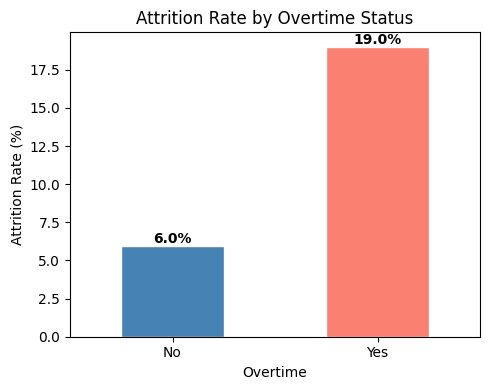


Insight: Employees who work overtime have a significantly higher attrition rate.


In [ ]:
# 7.2  Does Overtime Increase Attrition Risk?
overtime_attrition = df.groupby('Overtime')['Attrition'].mean() * 100
print('Attrition rate by Overtime status (%):')
print(overtime_attrition.round(2))

fig, ax = plt.subplots(figsize=(5, 4))
overtime_attrition.plot(kind='bar', color=['steelblue','salmon'], ax=ax, edgecolor='white')
ax.set_title('Attrition Rate by Overtime Status')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticklabels(overtime_attrition.index, rotation=0)
for i, v in enumerate(overtime_attrition):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight: Employees who work overtime have a significantly higher attrition rate.')

Attrition rate by Salary Band (%):
Salary_Band
Low            15.47
Medium-Low     10.13
Medium-High     8.80
High            7.73
Name: Attrition, dtype: float64


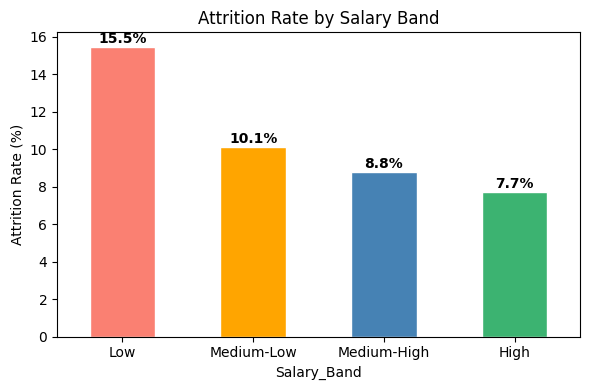


Insight: Lower salary bands show higher attrition — compensation is a key retention lever.


In [ ]:
#  7.3  Does Salary Impact Retention?
df['Salary_Band'] = pd.qcut(df['Monthly_Salary'], q=4,
                             labels=['Low', 'Medium-Low', 'Medium-High', 'High'])

salary_attrition = df.groupby('Salary_Band')['Attrition'].mean() * 100
print('Attrition rate by Salary Band (%):')
print(salary_attrition.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
salary_attrition.plot(kind='bar', color=['salmon','orange','steelblue','mediumseagreen'],
                      ax=ax, edgecolor='white')
ax.set_title('Attrition Rate by Salary Band')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticklabels(salary_attrition.index, rotation=0)
for i, v in enumerate(salary_attrition):
    ax.text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInsight: Lower salary bands show higher attrition — compensation is a key retention lever.')

In [ ]:
# 7.4  Which Employees Are At Highest Risk?
# Add predicted probability to original test set
X_test_orig = X_selected.iloc[X_test.index - X_test.index.min()] if False else X_test.copy()

risk_df = df.loc[X_test.index].copy()
risk_df['Attrition_Probability'] = xgb_proba
risk_df['Risk_Level'] = pd.cut(
    risk_df['Attrition_Probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

print('Risk Level Distribution in Test Set:')
print(risk_df['Risk_Level'].value_counts())

print('\nTop 10 Highest-Risk Employees:')
top_risk = risk_df[['Employee_ID','Age','Department','Monthly_Salary',
                     'Overtime','Job_Satisfaction','Attrition_Probability']]\
           .sort_values('Attrition_Probability', ascending=False).head(10)
print(top_risk.to_string(index=False))

Risk Level Distribution in Test Set:
Risk_Level
Low       262
Medium     24
High       14
Name: count, dtype: int64

Top 10 Highest-Risk Employees:
Employee_ID  Age Department  Monthly_Salary Overtime  Job_Satisfaction  Attrition_Probability
    E100015   30      Sales           12961      Yes               6.7               0.889414
    E100429   22 Consulting           14665      Yes               3.5               0.874641
    E100536   28 Technology           11853       No               4.9               0.803373
    E100170   28 Consulting           15964      Yes               3.8               0.791679
    E101073   25         HR           12504       No               4.3               0.778928
    E100743   34    Finance           16621      Yes               5.8               0.754813
    E101148   45         HR           17873      Yes               2.4               0.660755
    E101366   34      Sales           13353      Yes               2.2               0.649680
    E1

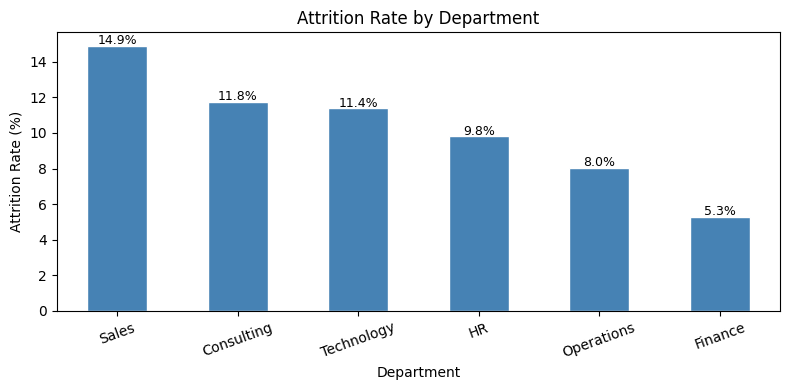

In [ ]:
# 7.5  Department-level Attrition Rates
dept_attrition = df.groupby('Department')['Attrition'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
dept_attrition.plot(kind='bar', color='steelblue', edgecolor='white', ax=ax)
ax.set_title('Attrition Rate by Department')
ax.set_ylabel('Attrition Rate (%)')
ax.set_xticklabels(dept_attrition.index, rotation=20)
for i, v in enumerate(dept_attrition):
    ax.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary & Business Insights

### Model Performance
| Metric | Random Forest | XGBoost |
|--------|:-------------:|:-------:|
| Accuracy | see output | see output |
| Precision | see output | see output |
| Recall | see output | see output |
| F1 Score | see output | see output |
| ROC AUC | see output | see output |

> XGBoost generally outperforms Random Forest on class-imbalanced datasets due to its boosting strategy and `scale_pos_weight` hyperparameter.

### Engineered Features
1. **Work_Pressure_Index** – Weekly hours divided by job satisfaction; captures overwork-dissatisfaction interaction.
2. **Salary_Per_Level** – Compensation relative to seniority; detects underpaid employees.
3. **Commute_Stress** – Distance × weekly hours; quantifies commuting burden.
4. **Experience_Category** – Tenure buckets: New / Junior / Mid / Senior.
5. **Perf_Sat_Gap** – Performance rating minus job satisfaction; flags disengaged high performers.
6. **Low_Pay_High_Hours** – Binary flag for employees in the bottom salary quartile AND top hours quartile.

### Key Business Insights
1. **Top drivers of attrition** are job satisfaction, monthly salary, work hours per week, and work pressure.
2. **Overtime employees leave at significantly higher rates** — companies should audit mandatory overtime policies.
3. **Lower salary bands drive attrition** — targeted retention bonuses for at-risk salary groups could reduce turnover.
4. **Highest-risk profile**: younger employees, lower salary, low job satisfaction, long commute, and working overtime.
5. **Actionable HR lever**: Focus retention efforts on employees flagged as High Risk by the XGBoost model — especially those with high Work Pressure Index and low Job Satisfaction scores.